In [26]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

X_train=pd.read_csv(r"../data/X_train.csv")
y_train=pd.read_csv(r"../data/Y_train.csv")


In [27]:
def feature_to_eda(df):
    df = df.copy()
    seq_cols = [f"feature_{i}" for i in range(1, 67)]
    # Length 
    df["length"] = df[seq_cols].notna().sum(axis=1)

    # Unique actions
    df["nunique"] = df[seq_cols].nunique(axis=1, dropna=True)

    #  Duplicate ratio 
    df["dup_ratio"] = 1 - (df["nunique"] / df["length"].replace(0, np.nan))

    # First action 
    df["first_item"] = df[seq_cols].bfill(axis=1).iloc[:, 0]

    # Last action
    df["last_item"] = df[seq_cols].ffill(axis=1).iloc[:, -1]

    # Most freq action (Mode)
    df["mode_val"] = df[seq_cols].mode(axis=1)[0]

    # Action dominance (Tỷ lệ của hành động xuất hiện nhiều nhất)
    mode_counts = (df[seq_cols].values == df[["mode_val"]].values).sum(axis=1)
    df["action_dominance"] = mode_counts / df["length"].replace(0, np.nan)

    # Rare actions
    all_actions_series = df[seq_cols].stack()
    actions_count = all_actions_series.value_counts()

    rare_threshold = actions_count.quantile(0.05)
    rare_actions = actions_count[actions_count <= rare_threshold].index.tolist()
    
    # Chuyển rare_actions thành set để kiểm tra nhanh hơn
    rare_actions_set = set(rare_actions)
    df["n_rare_actions"] = df[seq_cols].isin(rare_actions_set).sum(axis=1)
    df["rare_action_ratio"] = df["n_rare_actions"] / df["length"].replace(0, np.nan)

    # Entropy 
    from collections import Counter
    def calculate_entropy(row, cols):
        seq = row[cols].dropna().values
        if len(seq) == 0: 
            return 0
        
        counts = Counter(seq)
        probs = np.array(list(counts.values())) / len(seq)
        return -np.sum(probs * np.log2(probs + 1e-9))
    
    df["entropy"] = df.apply(lambda x: calculate_entropy(x, seq_cols), axis=1)

    #Transition 
    def get_transition_features(row, cols):
    
        actions = row[cols].dropna().values
        if len(actions) < 2:
            return 0, 0
        
        # Tính số lần chuyển đổi (t khác t-1)
        transitions = np.sum(actions[1:] != actions[:-1])
        ratio = transitions / (len(actions) - 1)
        return transitions, ratio

    df[['n_transitions', 'transition_ratio']] = df.apply(
        lambda x: pd.Series(get_transition_features(x, seq_cols)), axis=1
    )
        
    
    return df


X_train_feature = feature_to_eda(X_train)
X_train_feature.head()

,id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,dup_ratio,first_item,last_item,mode_val,action_dominance,n_rare_actions,rare_action_ratio,entropy,n_transitions,transition_ratio
0,c0dge,4347,4491,20278,975.0,103.0,4491.0,4425.0,1081.0,NaN,...,0.125,4347.0,1081.0,4491.0,0.250000,0,0.0,2.750000,7.0,1.0
1,u0w7z,4347,105,108,105.0,881.0,735.0,867.0,105.0,4187.0,...,0.250,4347.0,1071.0,105.0,0.333333,0,0.0,2.918296,11.0,1.0
2,r51ws,20278,1059,103,20278.0,1027.0,NaN,NaN,NaN,NaN,...,0.200,20278.0,1027.0,20278.0,0.400000,0,0.0,1.921928,4.0,1.0
3,levt9,760,1165,105,946.0,103.0,164.0,889.0,105.0,15342.0,...,0.100,760.0,1059.0,105.0,0.200000,0,0.0,3.121928,9.0,1.0
4,l6mgh,688,1433,709,1338.0,621.0,4275.0,905.0,2602.0,606.0,...,0.200,688.0,3065.0,1433.0,0.085714,0,0.0,4.707715,34.0,1.0


In [28]:
train_df= X_train_feature.merge(y_train,on= "id")
train_df.head(5)

,id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,rare_action_ratio,entropy,n_transitions,transition_ratio,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6
0,c0dge,4347,4491,20278,975.0,103.0,4491.0,4425.0,1081.0,NaN,...,0.0,2.750000,7.0,1.0,3,5,61,5,9,3
1,u0w7z,4347,105,108,105.0,881.0,735.0,867.0,105.0,4187.0,...,0.0,2.918296,11.0,1.0,3,2,13,12,1,95
2,r51ws,20278,1059,103,20278.0,1027.0,NaN,NaN,NaN,NaN,...,0.0,1.921928,4.0,1.0,1,1,67,1,1,64
3,levt9,760,1165,105,946.0,103.0,164.0,889.0,105.0,15342.0,...,0.0,3.121928,9.0,1.0,12,1,16,1,1,57
4,l6mgh,688,1433,709,1338.0,621.0,4275.0,905.0,2602.0,606.0,...,0.0,4.707715,34.0,1.0,8,15,70,9,20,42


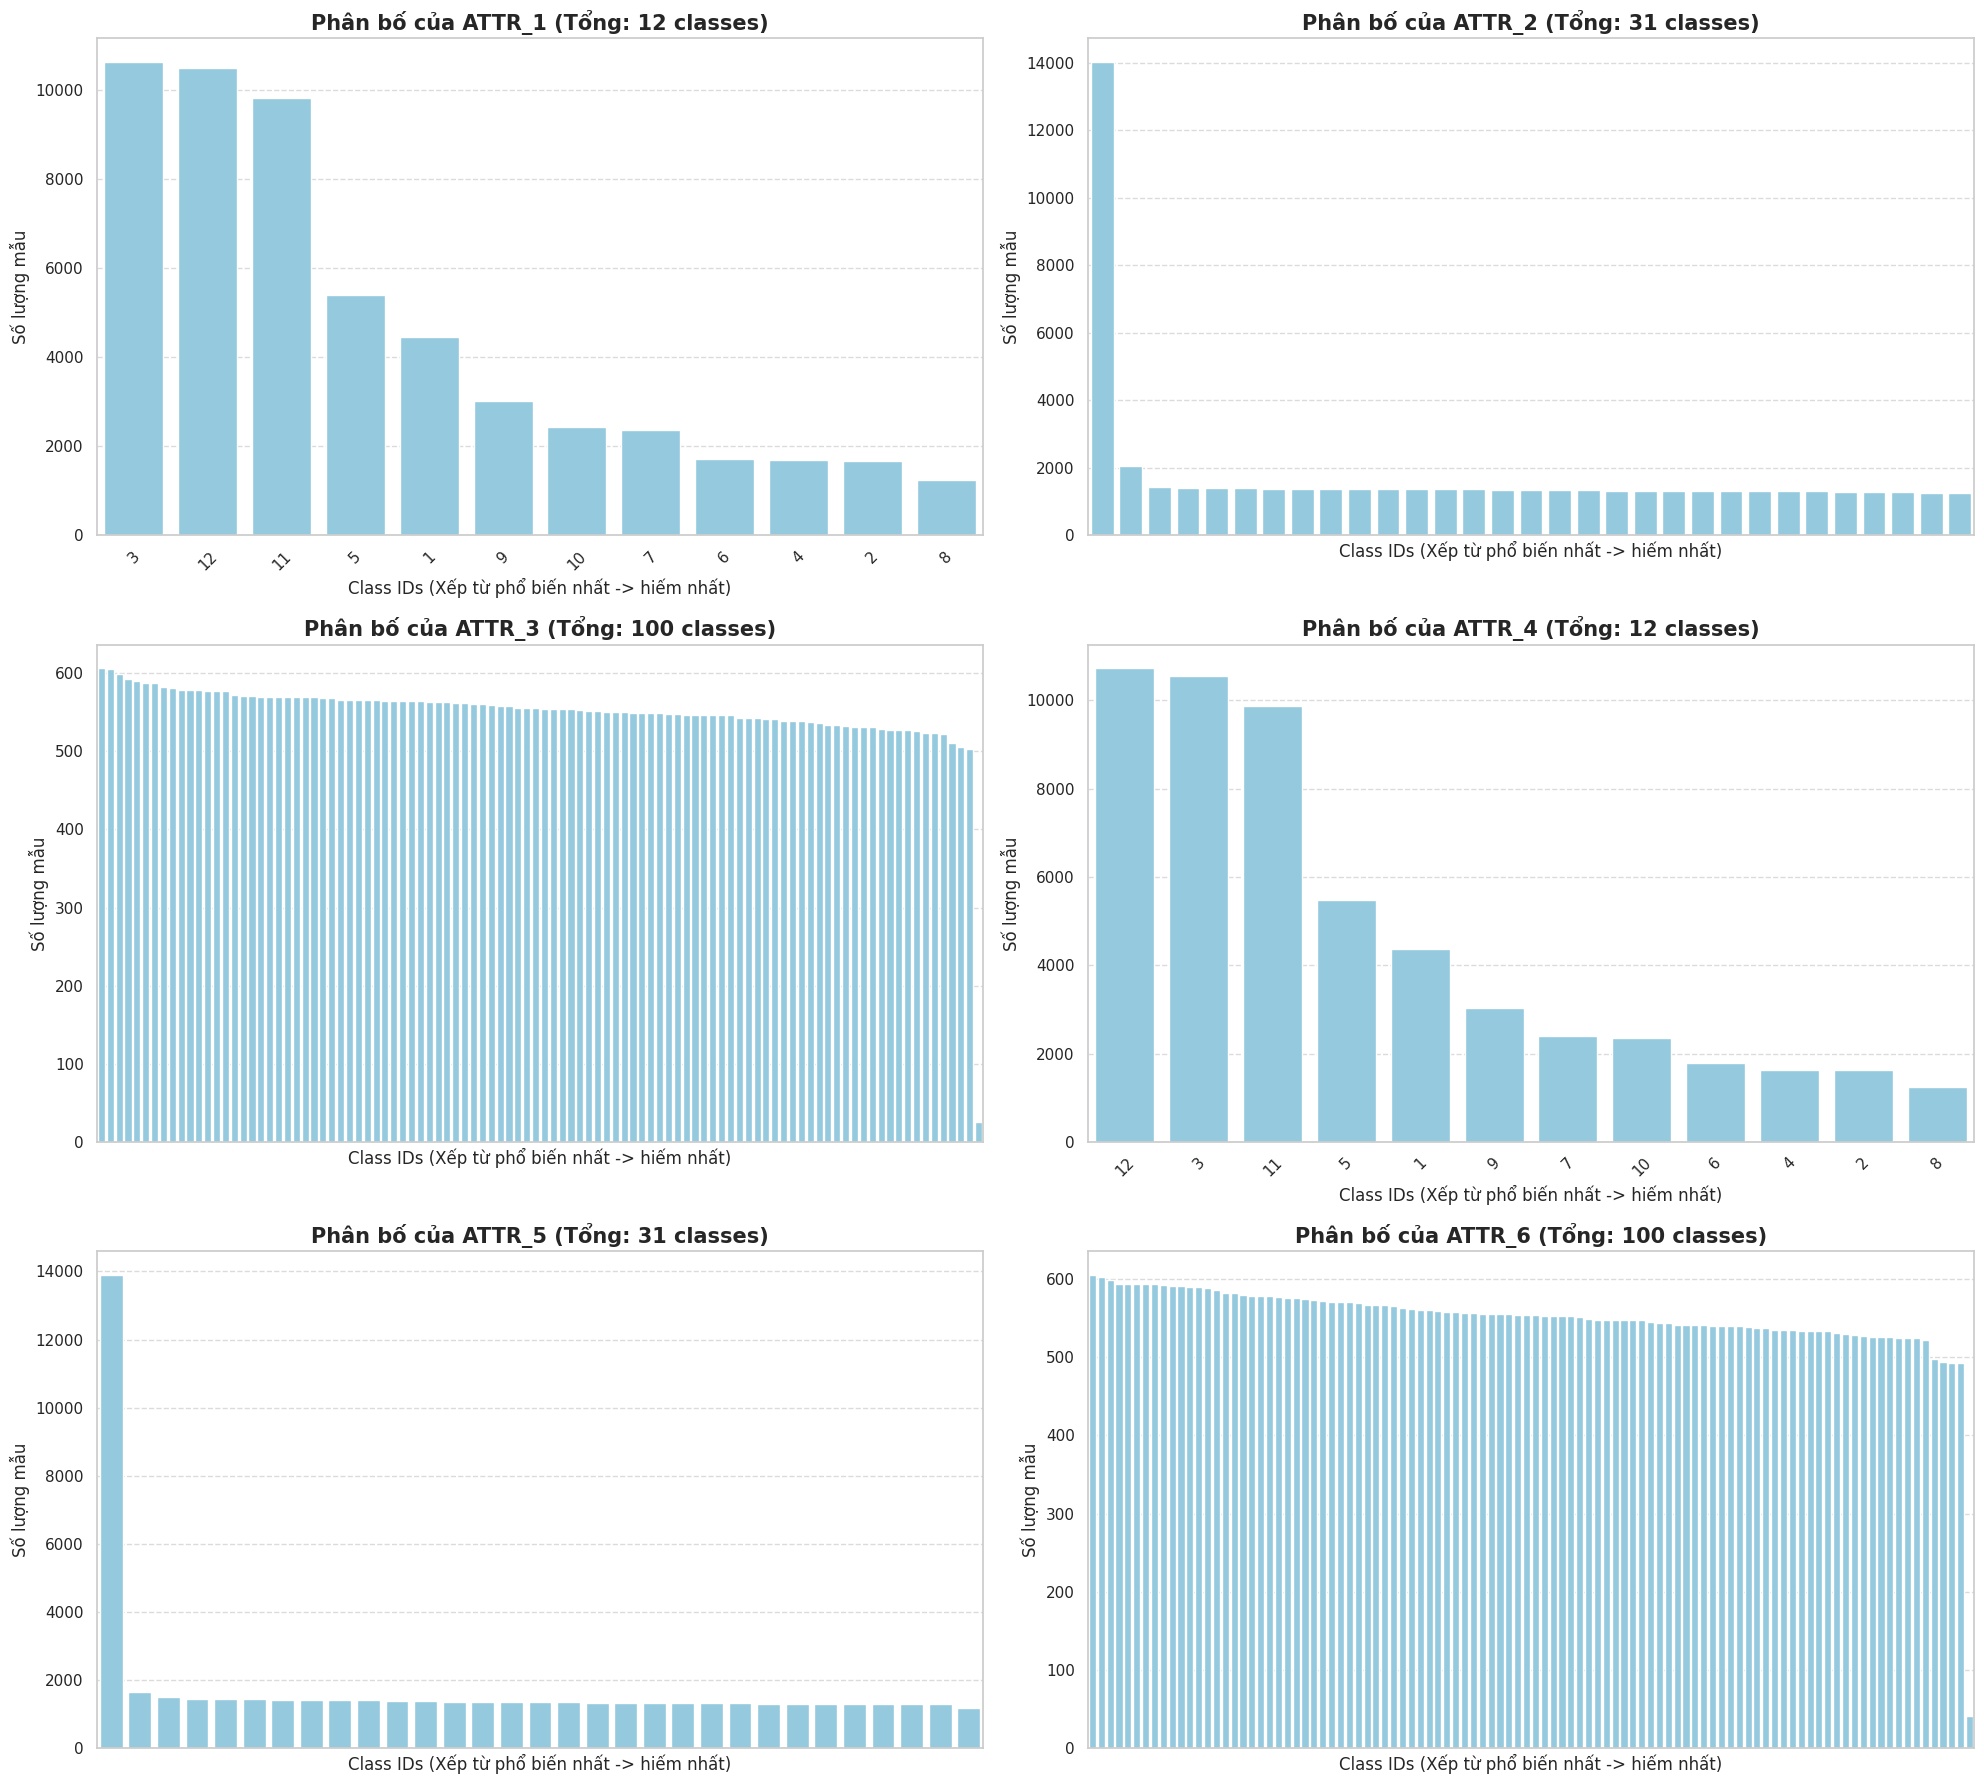

In [29]:
targets = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']

# 3. Cài đặt khung tranh khổng lồ (3 Hàng, 2 Cột)
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
axes = axes.flatten() # Trải phẳng mảng axes để dễ lặp

# 4. Vẽ từng nhãn một
for i, col in enumerate(targets):
    # Đếm số lượng và sắp xếp giảm dần
    class_counts = y_train[col].value_counts().sort_values(ascending=False)
    
    # Vẽ Barplot
    sns.barplot(
        x=class_counts.index, 
        y=class_counts.values, 
        ax=axes[i], 
        color='skyblue', 
        order=class_counts.index
    )
    
    # Trang trí đồ thị
    axes[i].set_title(f'Phân bố của {col.upper()} (Tổng: {len(class_counts)} classes)', fontsize=15, fontweight='bold')
    axes[i].set_ylabel('Số lượng mẫu', fontsize=12)
    axes[i].set_xlabel('Class IDs (Xếp từ phổ biến nhất -> hiếm nhất)', fontsize=12)
    
    # XỬ LÝ CHỐNG RỐI MẮT:
    if len(class_counts) > 30:
        axes[i].set_xticks([]) # Ẩn tên class nếu có quá nhiều (như attr_3, attr_6)
    else:
        axes[i].tick_params(axis='x', rotation=45) # Nghiêng chữ nếu ít class

    # Thêm đường lưới ngang để dễ gióng số
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Căn chỉnh khoảng cách giữa các đồ thị cho đẹp
plt.tight_layout()
plt.show()

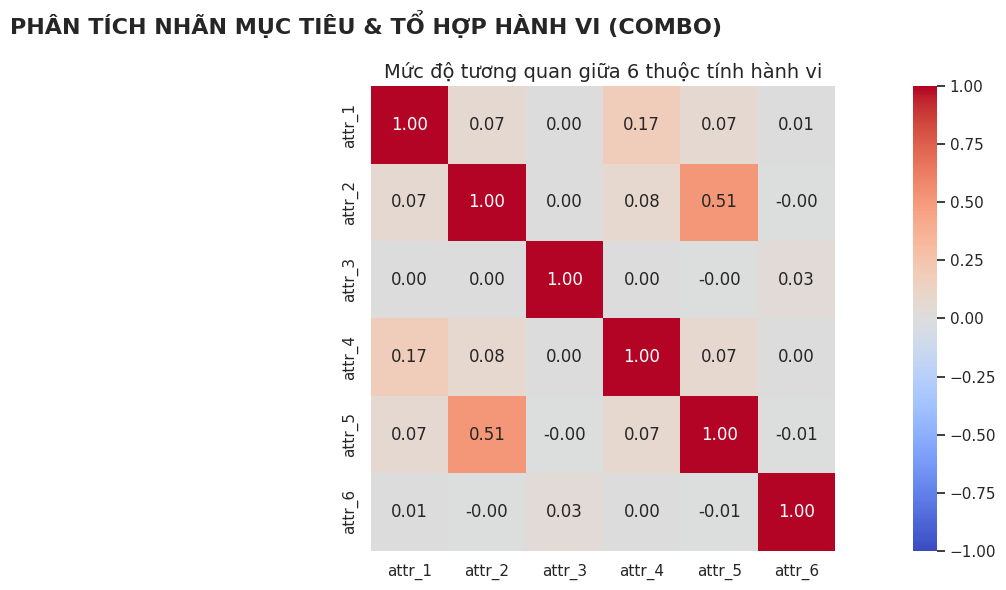

In [30]:
sns.set_theme(style="whitegrid", palette="muted")
# Tạo khung gồm 1 hàng, 2 cột
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
fig.suptitle('PHÂN TÍCH NHÃN MỤC TIÊU & TỔ HỢP HÀNH VI (COMBO)', fontsize=16, fontweight='bold')

# 2. Ma trận tương quan giữa 6 thuộc tính (Correlation Heatmap)
attr_cols = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']
# Lưu ý: Do là biến phân loại (Categorical), dùng phương pháp Spearman để xem xét thứ bậc tạm thời
corr_matrix = train_df[attr_cols].corr(method='spearman') 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes, square=True)
axes.set_title('Mức độ tương quan giữa 6 thuộc tính hành vi', fontsize=14)

plt.tight_layout()
plt.show()

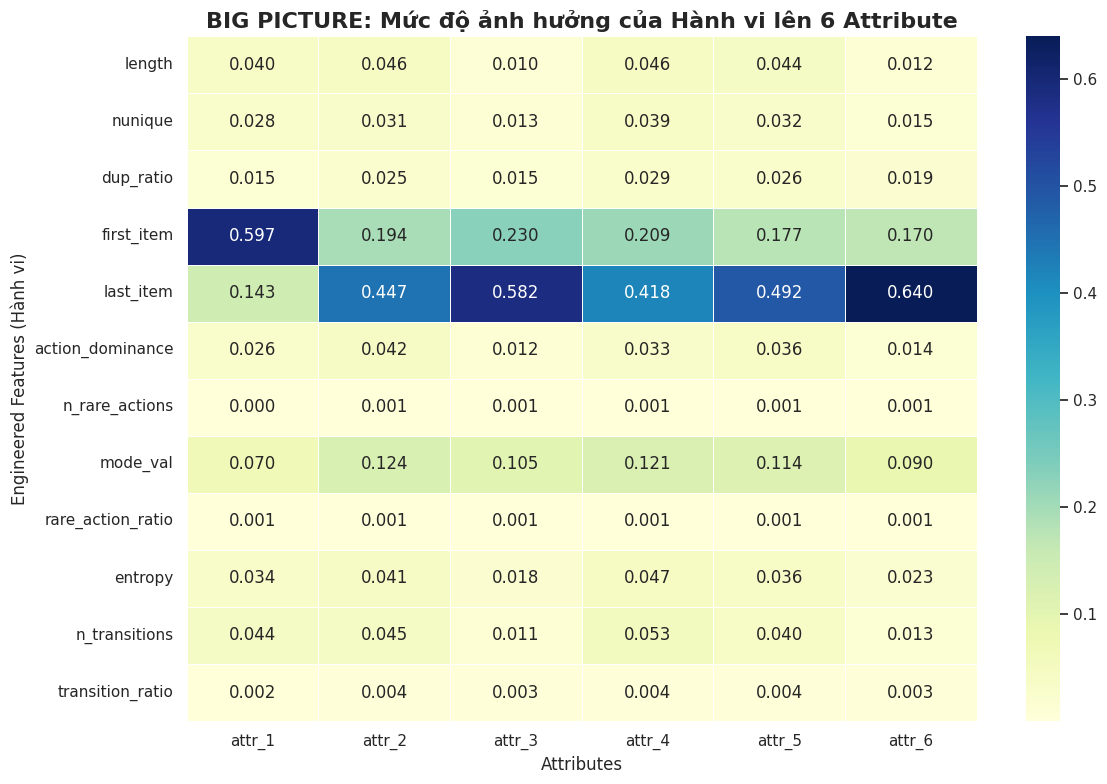

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

def plot_big_picture_heatmap(df_feature, target_cols=['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']):
    # 1. Xác định danh sách các feature chúng ta đã tạo ra
    # Loại bỏ các cột ID hoặc các cột sequence gốc để chỉ tập trung vào "Behavioral Features"
    behavior_features = [
        'length', 'nunique', 'dup_ratio','first_item','last_item',
        'action_dominance', 'n_rare_actions','mode_val', 'rare_action_ratio', 
        'entropy', 'n_transitions', 'transition_ratio'
    ]
    
    # Chuẩn bị bảng kết quả
    importance_matrix = pd.DataFrame(index=behavior_features)
    

    
    for target in target_cols:
        # Loại bỏ NaN để tránh lỗi khi train model nhanh
        temp_df = df_feature[behavior_features + [target]].dropna()
        
        X = temp_df[behavior_features]
        y = LabelEncoder().fit_transform(temp_df[target]) # Mã hóa nhãn (Class 3, 11... -> 0, 1...)
        
        # Sử dụng RandomForest để lấy Feature Importance (Nhanh và chính xác)
        model = RandomForestClassifier(n_estimators=50, random_state=42)
        model.fit(X, y)
        
        # Lưu kết quả vào ma trận
        importance_matrix[target] = model.feature_importances_

    # 2. Vẽ Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(importance_matrix, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=.5)
    
    plt.title("BIG PICTURE: Mức độ ảnh hưởng của Hành vi lên 6 Attribute", fontsize=16, fontweight='bold')
    plt.xlabel("Attributes", fontsize=12)
    plt.ylabel("Engineered Features (Hành vi)", fontsize=12)
    plt.tight_layout()
    plt.show()

# CÁCH CHẠY:
plot_big_picture_heatmap(train_df)


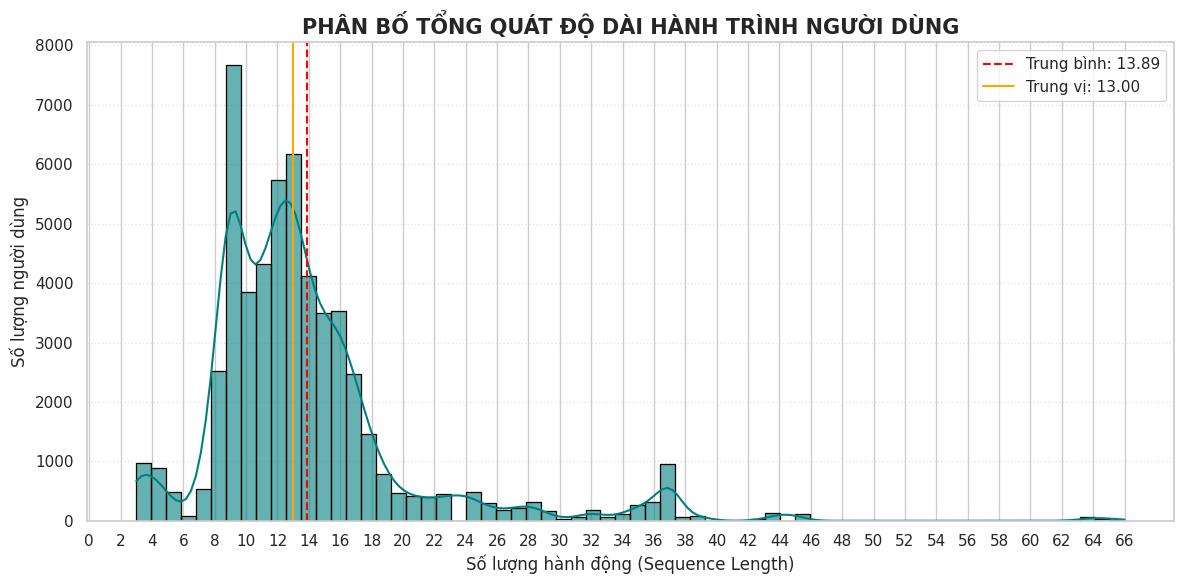

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_general_seq_length(df):

    
    # 2. Thiết lập cấu hình vẽ
    plt.figure(figsize=(12, 6))
    
    # Vẽ Histogram kết hợp KDE
    sns.histplot(df['length'], bins=66, kde=True, color='teal', edgecolor='black', alpha=0.6)
    
    # 3. Thêm các đường chỉ số thống kê quan trọng
    mean_val = df['length'].mean()
    median_val = df['length'].median()
    
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Trung bình: {mean_val:.2f}')
    plt.axvline(median_val, color='orange', linestyle='-', label=f'Trung vị: {median_val:.2f}')
    
    # Định dạng biểu đồ
    plt.title("PHÂN BỐ TỔNG QUÁT ĐỘ DÀI HÀNH TRÌNH NGƯỜI DÙNG", fontsize=15, fontweight='bold')
    plt.xlabel("Số lượng hành động (Sequence Length)", fontsize=12)
    plt.ylabel("Số lượng người dùng", fontsize=12)
    plt.xticks(range(0, 67, 2))
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Gọi hàm
plot_general_seq_length(X_train_feature)

/tmp/ipykernel_12002/4065348896.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cliff_actions.index.astype(str), y=top_cliff_actions.values, ax=axes[0], palette='Reds_r')
/tmp/ipykernel_12002/4065348896.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='peak_group', y='dup_ratio', ax=axes[1], palette='viridis', order=['1. Vách đá (8-20)', '2. Trung bình (20-40)', '3. Về đích (63-66)'])


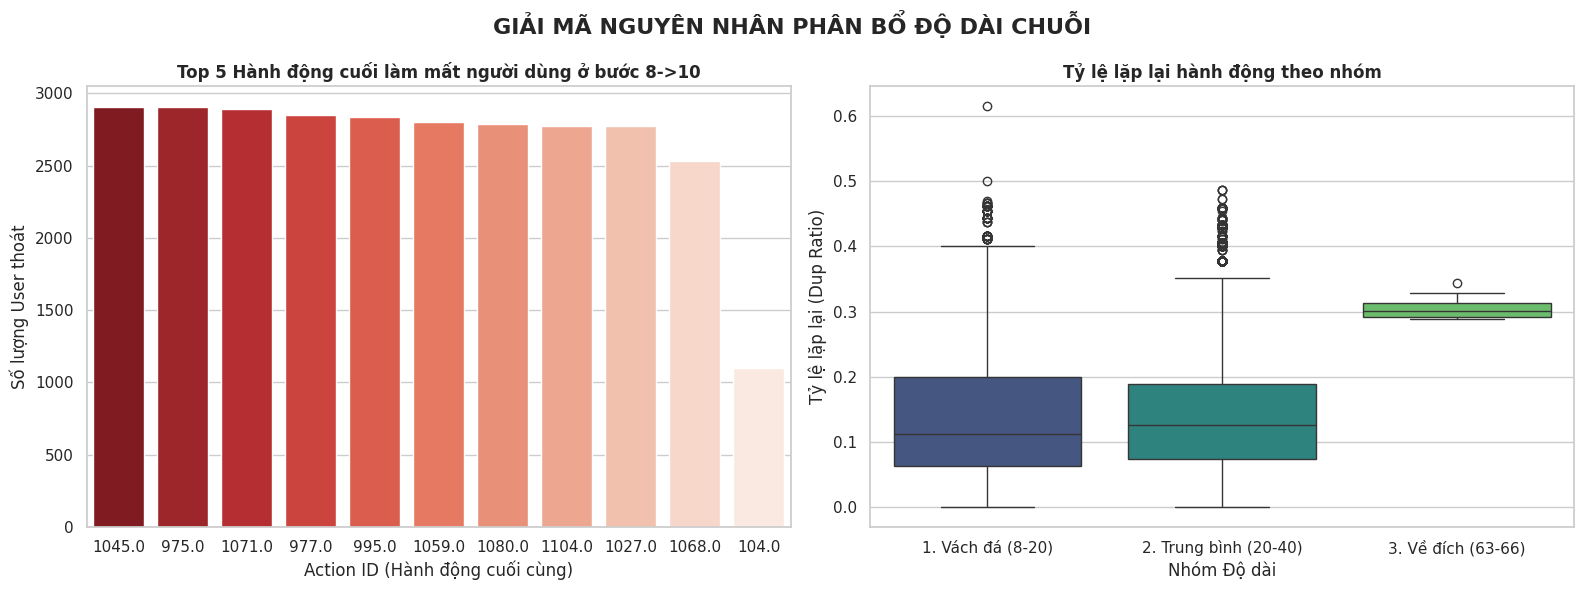

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_length_root_cause(df):
    # 1. Tính toán seq_length và các feature hành vi
    seq_cols = [f"feature_{i}" for i in range(1, 66)]
    

    # 2. Phân nhóm theo các "Đỉnh" từ biểu đồ phân bố
    def group_peaks(length):
        if 8 <= length <= 20: return '1. Vách đá (8-20)'
        elif 20 <= length <= 40: return '2. Trung bình (20-40)'
        elif length >= 63: return '3. Về đích (63-66)'
        else: return 'Khác'
        
    df['peak_group'] = df['length'].apply(group_peaks)
    
    # 3. Vẽ biểu đồ tìm nguyên nhân
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_style("whitegrid")
    
    df_plot = df[df['peak_group'] != 'Khác'].copy()
    
    # Biểu đồ 1: Tại sao họ chết ở "Vách đá"? (Last Action)
    cliff_df = df_plot[df_plot['peak_group'] == '1. Vách đá (8-20)']
    top_cliff_actions = cliff_df['last_item'].value_counts().head(11)
    
    sns.barplot(x=top_cliff_actions.index.astype(str), y=top_cliff_actions.values, ax=axes[0], palette='Reds_r')
    axes[0].set_title("Top 5 Hành động cuối làm mất người dùng ở bước 8->10", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Số lượng User thoát")
    axes[0].set_xlabel("Action ID (Hành động cuối cùng)")
    
    # Biểu đồ 2: Tại sao họ đi được dài? (Dup Ratio)
    sns.boxplot(data=df_plot, x='peak_group', y='dup_ratio', ax=axes[1], palette='viridis', order=['1. Vách đá (8-20)', '2. Trung bình (20-40)', '3. Về đích (63-66)'])
    axes[1].set_title("Tỷ lệ lặp lại hành động theo nhóm", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Tỷ lệ lặp lại (Dup Ratio)")
    axes[1].set_xlabel("Nhóm Độ dài")

    plt.suptitle("GIẢI MÃ NGUYÊN NHÂN PHÂN BỔ ĐỘ DÀI CHUỖI", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

analyze_length_root_cause(X_train_feature)

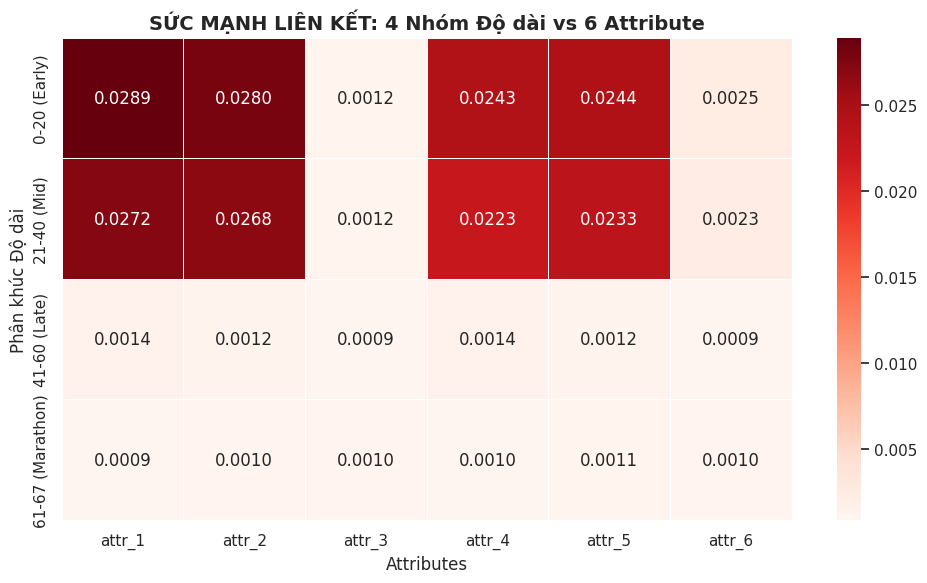

In [41]:

from sklearn.metrics import mutual_info_score


def plot_length_group_vs_attrs_heatmap(df):

    
    bins = [0, 20, 40, 60, 66]
    labels = ['0-20 (Early)', '21-40 (Mid)', '41-60 (Late)', '61-67 (Marathon)']
    df['length_group'] = pd.cut(df['length'], bins=bins, labels=labels)
    
    # 2. Tính toán sức mạnh liên kết (Mutual Information)
    attrs = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']
    
    # Tạo ma trận rỗng
    mi_matrix = pd.DataFrame(index=labels, columns=attrs)
    
    # Vì Mutual Information bình thường tính cho toàn bộ cột, 
    # để xem CỤ THỂ từng nhóm (vd: nhóm Early) ảnh hưởng thế nào đến Attr,
    # ta tạo biến nhị phân cho từng nhóm (vd: Có phải Early không? 1/0)
    
    for label in labels:
        is_group = (df['length_group'] == label).astype(int)
        for attr in attrs:
            # Drop NaN nếu có
            valid_idx = df[attr].notna() & is_group.notna()
            # Tính MI score
            score = mutual_info_score(is_group[valid_idx], df.loc[valid_idx, attr].astype(str))
            mi_matrix.loc[label, attr] = score
            
    # Ép kiểu float để vẽ Heatmap
    mi_matrix = mi_matrix.astype(float)
    
    # 3. Vẽ biểu đồ Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(mi_matrix, annot=True, cmap='Reds', fmt=".4f", linewidths=.5)
    
    plt.title("SỨC MẠNH LIÊN KẾT: 4 Nhóm Độ dài vs 6 Attribute", fontsize=14, fontweight='bold')
    plt.ylabel("Phân khúc Độ dài", fontsize=12)
    plt.xlabel("Attributes", fontsize=12)
    
    plt.tight_layout()
    plt.show()

plot_length_group_vs_attrs_heatmap(train_df)

/tmp/ipykernel_12002/2204341833.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=analysis_res['Count'], y=analysis_res.index, palette=colors)
/tmp/ipykernel_12002/2204341833.py:37: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  ax = sns.barplot(x=analysis_res['Count'], y=analysis_res.index, palette=colors)


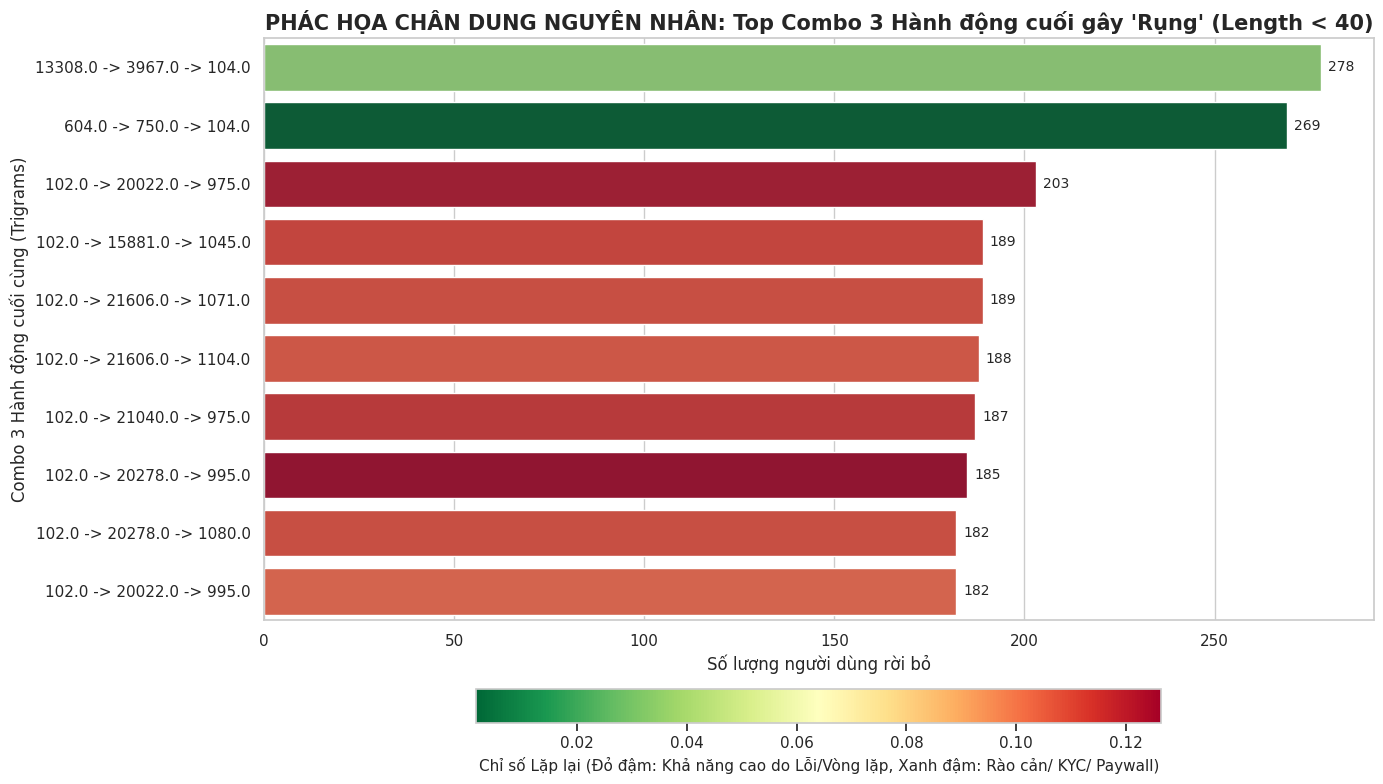

In [42]:

def plot_trigrams_cause_analysis(df, drop_threshold=40):
    # 1. Chuẩn bị dữ liệu và feature
    seq_cols = [f"feature_{i}" for i in range(1, 67)]    

    # 2. Lọc nhóm "Rụng sớm" và lấy 3 hành động cuối (Last 3)
    drop_df = df[df['length'] < drop_threshold].copy()
    
    def get_last_3_actions(row):
        l = int(row['length'])
        if l < 3: return np.nan
        # Lấy combo 3 cột cuối cùng (ví dụ length=8, lấy feature_6, feature_7, feature_8)
        actions = row[seq_cols[l-3:l]].astype(str).tolist()
        return " -> ".join(actions)
    
    drop_df['last_3_trigram'] = drop_df.apply(get_last_3_actions, axis=1)
    
    # 3. Tính toán Top 10 Trigrams và chỉ số đi kèm
    trigram_counts = drop_df['last_3_trigram'].value_counts().head(10)
    
    # Tạo bảng kết quả phân tích
    analysis_res = pd.DataFrame(index=trigram_counts.index)
    analysis_res['Count'] = trigram_counts.values
    
    # Tính dup_ratio trung bình cho từng Trigram
    for trigram in trigram_counts.index:
        avg_dup = drop_df[drop_df['last_3_trigram'] == trigram]['dup_ratio'].mean()
        analysis_res.loc[trigram, 'Avg_Dup_Ratio'] = avg_dup

    # 4. Vẽ biểu đồ Bar chart kết hợp Color Code
    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    
    # Màu sắc thể hiện nguyên nhân (Đỏ: Lỗi/Vòng lặp, Xanh: Rào cản/Đi một mạch)
    norm = plt.Normalize(analysis_res['Avg_Dup_Ratio'].min(), analysis_res['Avg_Dup_Ratio'].max())
    colors = plt.cm.RdYlGn_r(norm(analysis_res['Avg_Dup_Ratio'])) # _r để đảo ngược Green -> Red
    
    ax = sns.barplot(x=analysis_res['Count'], y=analysis_res.index, palette=colors)
    
    # Thêm nhãn số liệu và giải thích màu
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

    # Thêm Colorbar để Dev/Product hiểu màu sắc
    sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.1)
    cbar.set_label('Chỉ số Lặp lại (Đỏ đậm: Khả năng cao do Lỗi/Vòng lặp, Xanh đậm: Rào cản/ KYC/ Paywall)', fontsize=11)
    
    plt.title(f"PHÁC HỌA CHÂN DUNG NGUYÊN NHÂN: Top Combo 3 Hành động cuối gây 'Rụng' (Length < {drop_threshold})", fontsize=15, fontweight='bold')
    plt.xlabel("Số lượng người dùng rời bỏ")
    plt.ylabel("Combo 3 Hành động cuối cùng (Trigrams)")
    plt.tight_layout()
    plt.show()

plot_trigrams_cause_analysis(X_train_feature)

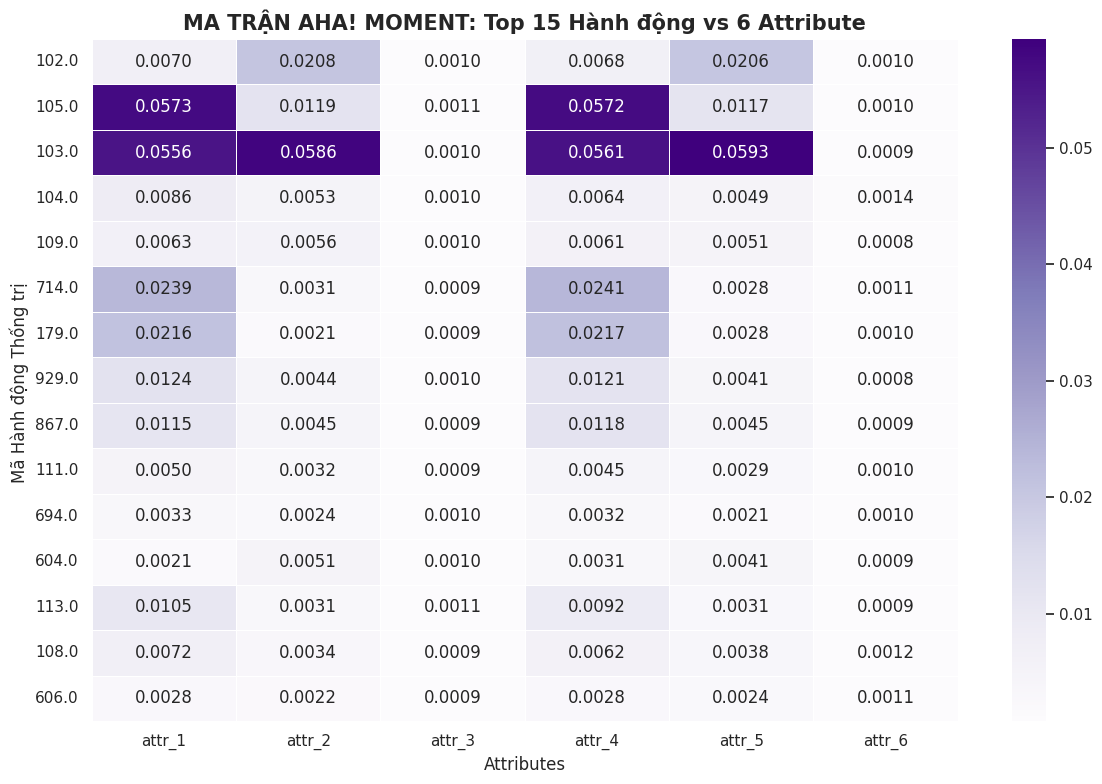

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
import numpy as np

def plot_aha_moments_matrix(df, top_n=15):
    # 1. Tìm "Hành động thống trị" (Action Dominance) của mỗi người dùng
    seq_cols = [f"feature_{i}" for i in range(1, 67)]
    
    # 2. Lấy Top N hành động thống trị phổ biến nhất toàn hệ thống
    top_actions = df['mode_val'].value_counts().head(top_n).index.tolist()
    
    attrs = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']
    mi_matrix = pd.DataFrame(index=top_actions, columns=attrs)
    
    # 3. Tính toán sức mạnh (Mutual Information) 
    for action in top_actions:
        # TẠO BIẾN ĐÚNG: is_dominant (1 nếu có action này, 0 nếu không)
        is_dominant = (df['mode_val'] == action).astype(int)
        
        for attr in attrs:
            valid_idx = df[attr].notna() & is_dominant.notna()
            
            # SỬA LỖI TẠI ĐÂY: Truyền đúng biến is_dominant vào hàm
            score = mutual_info_score(is_dominant[valid_idx], df.loc[valid_idx, attr].astype(str))
            mi_matrix.loc[action, attr] = score
            
    mi_matrix = mi_matrix.astype(float)    
    # 4. Vẽ biểu đồ Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(mi_matrix, annot=True, cmap='Purples', fmt=".4f", linewidths=.5)
    
    plt.title(f"MA TRẬN AHA! MOMENT: Top {top_n} Hành động vs 6 Attribute", fontsize=15, fontweight='bold')
    plt.ylabel("Mã Hành động Thống trị ", fontsize=12)
    plt.xlabel("Attributes", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    return mi_matrix

mi_matrix=plot_aha_moments_matrix(train_df, top_n=15)

/tmp/ipykernel_12002/2057606741.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_12002/2057606741.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_12002/2057606741.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=axes[i], palette='viridis')
/tmp/ipykernel_12002/2057606

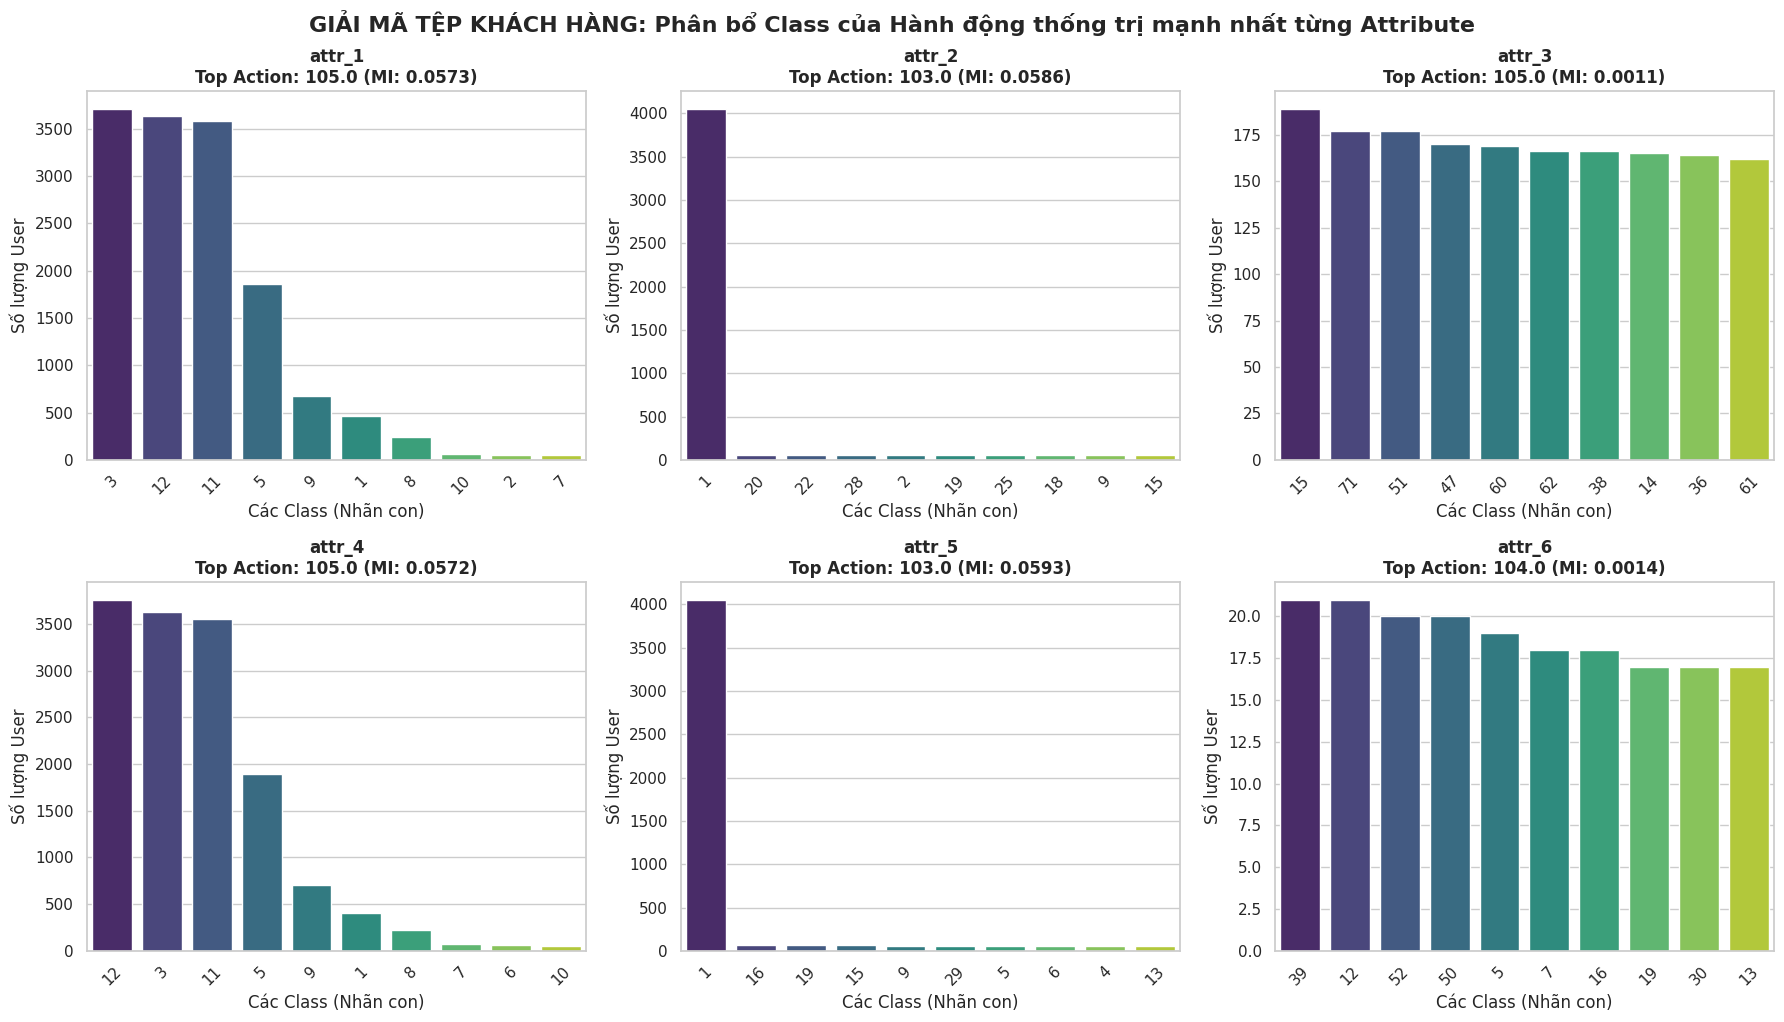

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_action_class_distribution(df, mi_matrix):
    attrs = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']
    
    # Tạo khung vẽ 6 biểu đồ (2 hàng x 3 cột)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, attr in enumerate(attrs):
        # 1. Tìm mã hành động có điểm MI cao nhất cho Attribute này từ ma trận
        best_action = mi_matrix[attr].astype(float).idxmax()
        max_score = mi_matrix.loc[best_action, attr]
        
        # 2. Lọc ra những người dùng có hành động thống trị là best_action này
        subset = df[df['mode_val'] == best_action]
        
        # Đếm số lượng người dùng rơi vào từng Class của Attribute này
        class_counts = subset[attr].value_counts().head(10) # Lấy top 10 class đông nhất cho dễ nhìn
        
        # 3. Vẽ biểu đồ cột
        sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=axes[i], palette='viridis')
        
        axes[i].set_title(f"{attr}\nTop Action: {best_action} (MI: {max_score:.4f})", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("Các Class (Nhãn con)")
        axes[i].set_ylabel("Số lượng User")
        axes[i].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    fig.suptitle("GIẢI MÃ TỆP KHÁCH HÀNG: Phân bổ Class của Hành động thống trị mạnh nhất từng Attribute", 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Cách chạy: 
# Truyền cái bảng df của bạn và cái biến mi_matrix (bảng điểm màu tím vừa nãy) vào hàm này
plot_top_action_class_distribution(train_df, mi_matrix)

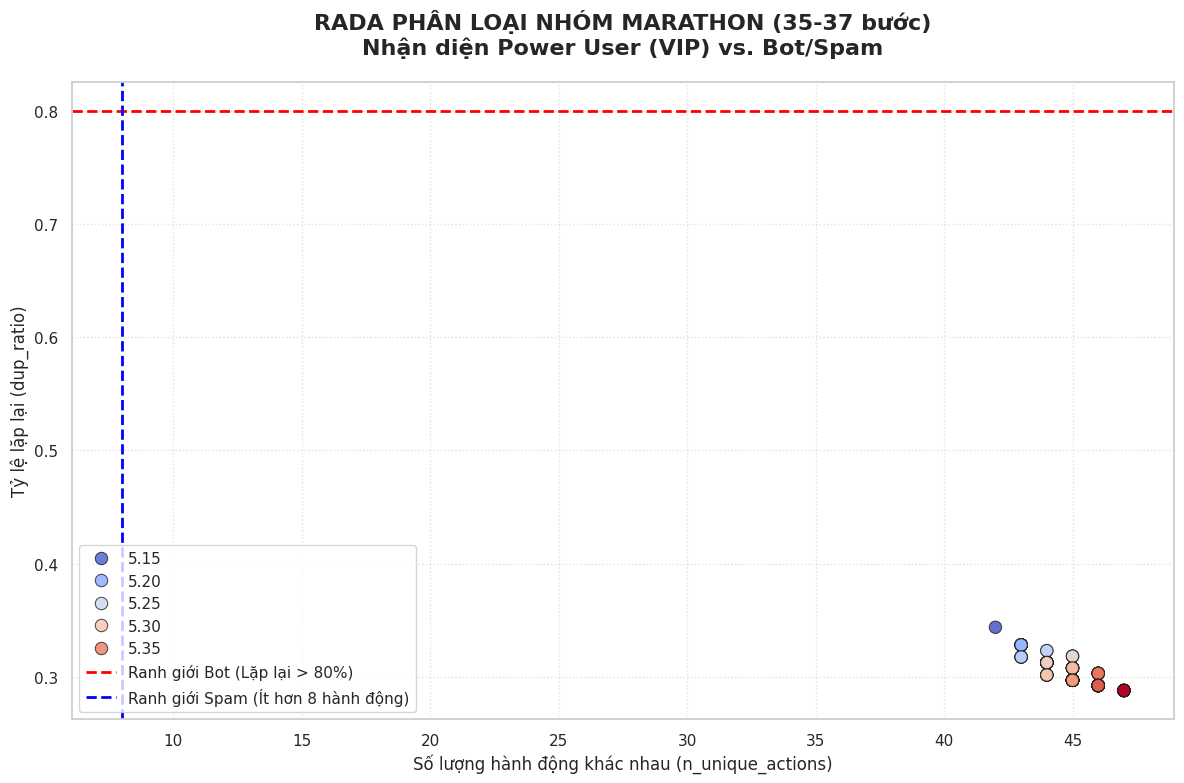

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_marathon_users_radar(df_features):
    # 1. Lọc ra nhóm chạy Marathon (Độ dài chuỗi >= 35 bước)
    marathon_df = df_features[df_features['length'] >= 60].copy()
    
    # Kiểm tra xem có ai ở độ dài này không để tránh lỗi
    if marathon_df.empty:
        print("Không có người dùng nào đạt 35 bước trở lên trong tập dữ liệu này.")
        return

    plt.figure(figsize=(12, 8))
    
    # 2. Vẽ biểu đồ phân tán (Scatter plot)
    # X: Số hành động độc nhất, Y: Tỷ lệ lặp lại, Màu sắc: Entropy (Độ bối rối)
    sns.scatterplot(
        data=marathon_df, 
        x='nunique', 
        y='dup_ratio', 
        hue='entropy', 
        palette='coolwarm', # Đỏ là bối rối/phong phú, Xanh là nhàm chán/lặp lại
        s=80, alpha=0.8, edgecolor='k'
    )

    # 3. Vẽ các đường ranh giới "Cảnh báo" (Có thể tinh chỉnh thông số sau khi xem hình)
    plt.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='Ranh giới Bot (Lặp lại > 80%)')
    plt.axvline(x=8, color='blue', linestyle='--', linewidth=2, label='Ranh giới Spam (Ít hơn 8 hành động)')

    # 4. Trang trí biểu đồ và thêm Chú thích (Annotations)
    plt.title("RADA PHÂN LOẠI NHÓM MARATHON (35-37 bước)\nNhận diện Power User (VIP) vs. Bot/Spam", 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Số lượng hành động khác nhau (n_unique_actions)", fontsize=12)
    plt.ylabel("Tỷ lệ lặp lại (dup_ratio)", fontsize=12)
    

    plt.legend(loc='lower left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Cách chạy:
plot_marathon_users_radar(X_train_feature)

/tmp/ipykernel_12002/1567258693.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rb_3_steps', ax=axes[0], palette='viridis')
/tmp/ipykernel_12002/1567258693.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rb_4_steps', ax=axes[1], palette='rocket')


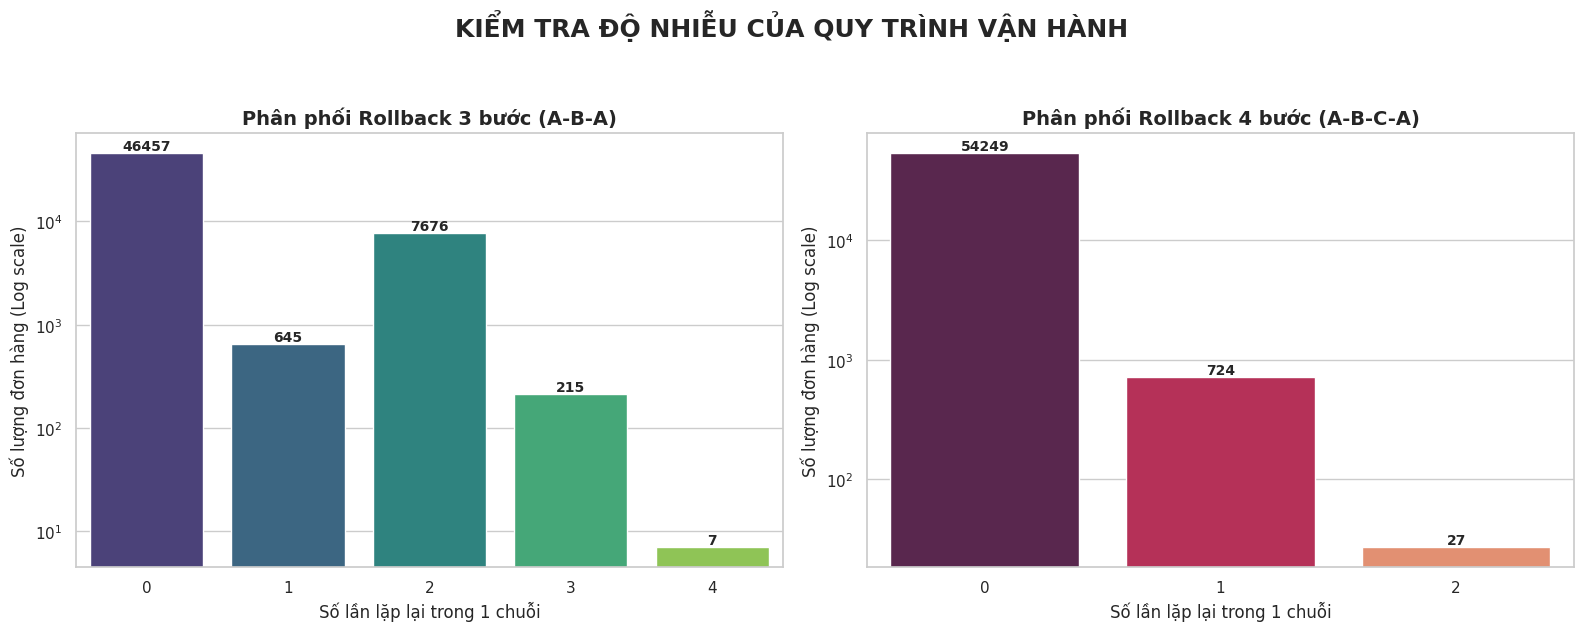

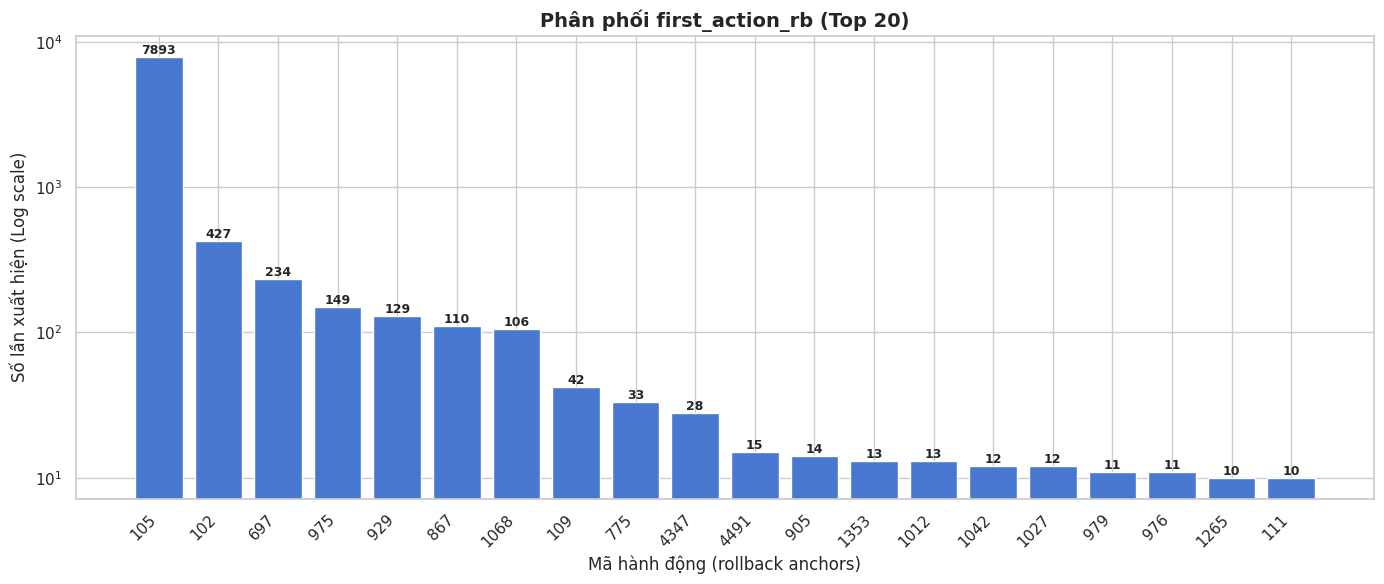

In [46]:
def count_rollbacks(sequence):
    seq = [x for x in sequence if pd.notnull(x) and x != 0]
    n = len(seq)
        
    rollback_3 = 0
    rollback_4 = 0
    rb3_actions=set()
    rb4_actions=set()
        
    if n < 3:
        return 0, 0
        
        # 1. Quét rollback 3 bước: A -> B -> A
    for i in range(n - 2):
            # Bước đầu và bước cuối của cụm 3 giống nhau, nhưng bước giữa phải khác
        if seq[i] == seq[i+2]:
            rollback_3 += 1
            rb3_actions.add(str(int(seq[i])))
                
        # 2. Quét rollback 4 bước: A -> B -> C -> A
    if n >= 4:
        for i in range(n - 3):
                # Bước đầu và bước cuối của cụm 4 giống nhau
            if seq[i] == seq[i+3]:
                    # Đảm bảo đây không phải là một chuỗi lặp đơn điệu (như A -> A -> A -> A)
                if seq[i] != seq[i+1] :
                    rollback_4 += 1
                    rb4_actions.add(str(int(seq[i])))
                        
    return rollback_3, rollback_4,list(rb3_actions),list(rb4_actions)

# Ví dụ áp dụng cho DataFrame
def apply_rollback_features(df):
    seq_cols = [f"feature_{i}" for i in range(1, 67)]
    results = df[seq_cols].apply(lambda row: count_rollbacks(row.values), axis=1)
# Bước 2: Bung kết quả ra thành các cột (Cách này nhanh và sạch nhất)
    res_df = pd.DataFrame(results.tolist(), index=df.index)
    df['rb_3_steps'] = res_df[0]
    df['rb_4_steps'] = res_df[1]

    # Bước 3: Gộp chi tiết mã lỗi và loại bỏ trùng lặp bằng set
    df['first_action_rb'] = [list(set(a + b)) for a, b in zip(res_df[2], res_df[3])]
    
    return df
train_df=apply_rollback_features(train_df)

def plot_rollback_distribution(df):
    # Thiết lập layout gồm 2 biểu đồ con
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_style("whitegrid")

    # 1. Phân phối Rollback 3 bước (A-B-A)
    sns.countplot(data=df, x='rb_3_steps', ax=axes[0], palette='viridis')
    axes[0].set_title('Phân phối Rollback 3 bước (A-B-A)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Số lần lặp lại trong 1 chuỗi')
    axes[0].set_ylabel('Số lượng đơn hàng (Log scale)')
    axes[0].set_yscale('log') # Dùng Log scale vì đa số sẽ là 0, cần log để thấy các cột nhỏ

    # 2. Phân phối Rollback 4 bước (A-B-C-A)
    sns.countplot(data=df, x='rb_4_steps', ax=axes[1], palette='rocket')
    axes[1].set_title('Phân phối Rollback 4 bước (A-B-C-A)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Số lần lặp lại trong 1 chuỗi')
    axes[1].set_ylabel('Số lượng đơn hàng (Log scale)')
    axes[1].set_yscale('log')

    # Thêm số liệu cụ thể trên đầu mỗi cột
    for ax in axes:
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.suptitle("KIỂM TRA ĐỘ NHIỄU CỦA QUY TRÌNH VẬN HÀNH", fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Chạy lệnh vẽ
plot_rollback_distribution(train_df)
def plot_first_action_rb_distribution(df, col='first_action_rb', top_k=20):
    """
    Vẽ phân phối các mã trong first_action_rb.
    - first_action_rb là list các mã (vd ['105','123']) hoặc string dạng "['105','123']"
    - Vẽ Top K mã xuất hiện nhiều nhất (log scale để nhìn rõ đuôi dài)
    """

    series = df[col].dropna()

    # Chuẩn hoá về list
    def to_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, (tuple, set)):
            return list(x)
        if isinstance(x, str):
            x = x.strip()
            if x == "" or x.lower() == "nan":
                return []
            try:
                v = ast.literal_eval(x)
                if isinstance(v, (list, tuple, set)):
                    return list(v)
                return [v]
            except Exception:
                # fallback nếu string không đúng format
                return [t.strip().strip("'").strip('"') for t in x.strip("[]").split(",") if t.strip()]
        return [x]

    lists = series.apply(to_list)

    # Flatten list-of-lists thành 1 list mã
    flat = []
    for lst in lists:
        for item in lst:
            if pd.isnull(item):
                continue
            try:
                flat.append(str(int(float(item))))  # chuẩn hoá về string số
            except Exception:
                flat.append(str(item))

    if len(flat) == 0:
        print("Không có dữ liệu first_action_rb để vẽ.")
        return

    counts = pd.Series(flat).value_counts()
    top = counts.head(top_k)

    plt.figure(figsize=(14, 6))
    plt.bar(top.index.astype(str), top.values)
    plt.title(f'Phân phối first_action_rb (Top {top_k})', fontsize=14, fontweight='bold')
    plt.xlabel('Mã hành động (rollback anchors)')
    plt.ylabel('Số lần xuất hiện (Log scale)')
    plt.yscale('log')
    plt.xticks(rotation=45, ha='right')

    # Ghi số lên cột
    for i, v in enumerate(top.values):
        plt.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Chạy lệnh vẽ
plot_first_action_rb_distribution(train_df, top_k=20)

/tmp/ipykernel_12002/4121060593.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


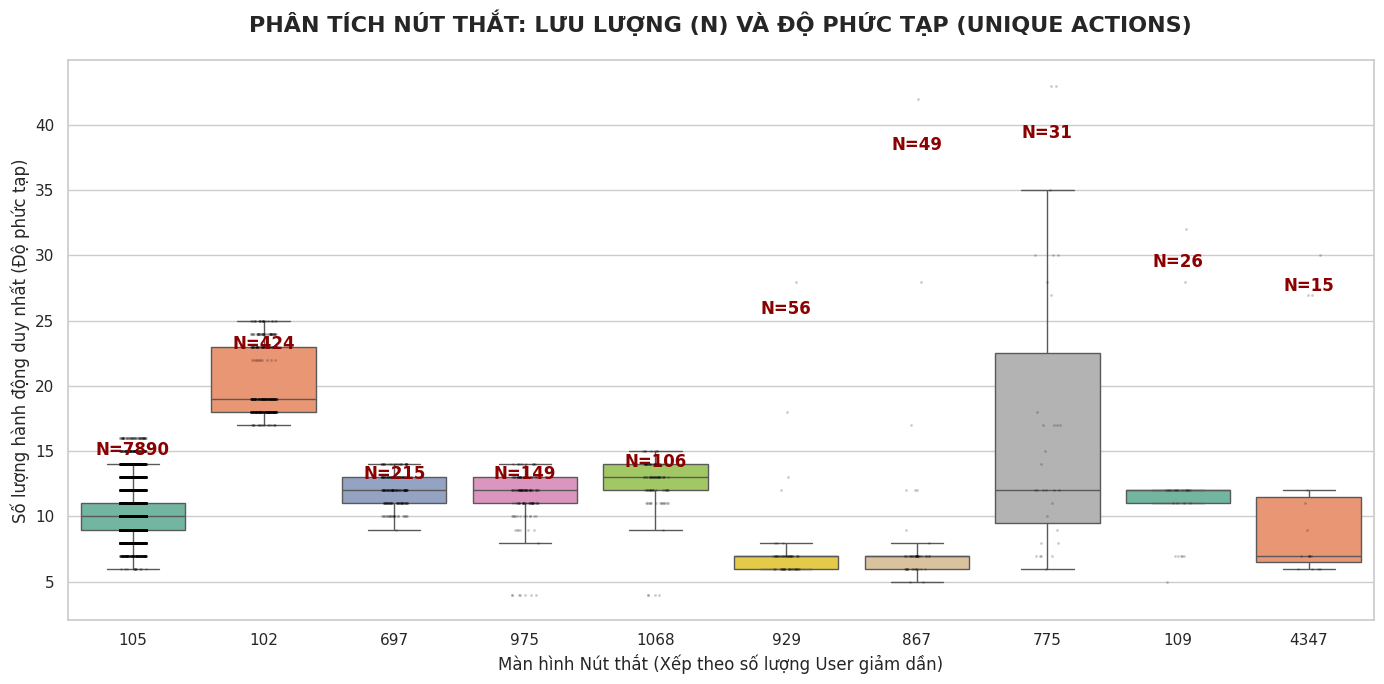

In [72]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Hàm trích xuất Anchor và Unique Count
def extract_simple_insight(row):
    seq = [str(int(x)) for x in row if pd.notnull(x) and x != 0]
    if not seq:
        return pd.Series([np.nan, 0])
    
    unique_actions = len(set(seq))
    
    first_action_rb = []
    
    # Loop 3 bước: A-B-A
    for i in range(len(seq) - 2):
        if seq[i] == seq[i+2] and seq[i] != seq[i+1]:
            first_action_rb.append(seq[i])
    
    # Loop 4 bước: A-B-C-A
    for i in range(len(seq) - 3):
        if (
            seq[i] == seq[i+3]
            and seq[i] != seq[i+1]
            and seq[i] != seq[i+2]
        ):
            first_action_rb.append(seq[i])
    
    anchor = Counter(first_action_rb).most_common(1)[0][0] if len(first_action_rb) > 0 else "NO_LOOP"
    
    return pd.Series([anchor, unique_actions])

# 2. Áp dụng vào bảng chính
seq_cols = [col for col in train_df.columns if str(col).startswith('feature_')]
train_df[['anchor_id', 'unique_count']] = train_df[seq_cols].apply(extract_simple_insight, axis=1)

# 3. Chuẩn bị dữ liệu vẽ
df_valid = train_df[train_df['anchor_id'] != 'NO_LOOP'].copy()
order = df_valid['anchor_id'].value_counts().index[:10]

# 4. Vẽ biểu đồ
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=df_valid,
    x='anchor_id',
    y='unique_count',
    order=order,
    palette='Set2',
    showfliers=False
)

sns.stripplot(
    data=df_valid,
    x='anchor_id',
    y='unique_count',
    order=order,
    color='black',
    size=2,
    alpha=0.2
)

counts = df_valid['anchor_id'].value_counts()
for i, anchor in enumerate(order):
    y_max = df_valid[df_valid['anchor_id'] == anchor]['unique_count'].max()
    ax.text(
        i,
        y_max * 0.9,
        f'N={counts[anchor]}',
        ha='center',
        va='bottom',
        fontweight='bold',
        color='darkred'
    )

plt.title('PHÂN TÍCH NÚT THẮT: LƯU LƯỢNG (N) VÀ ĐỘ PHỨC TẠP (UNIQUE ACTIONS)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Màn hình Nút thắt (Xếp theo số lượng User giảm dần)', fontsize=12)
plt.ylabel('Số lượng hành động duy nhất (Độ phức tạp)', fontsize=12)
plt.tight_layout()
plt.show()